<a href="https://colab.research.google.com/github/Titinha2004/Apontamentos-ISEC/blob/master/AD2526_P5B_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Setup, Version check and Common imports

# Python ≥ 3.7 is required
import sys
assert sys.version_info >= (3, 7)


# TensorFlow ≥ 2.8 is required
import tensorflow as tf
from packaging import version

assert version.parse(tf.__version__) >= version.parse("2.8.0")

# Common imports
import numpy as np
import os
import pandas as pd

from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

print('Python version: ', sys.version_info)
print('TF version: ', tf.__version__)
print('Keras version: ', keras.__version__)
print('GPU is', 'available' if tf.config.list_physical_devices('GPU') else 'NOT AVAILABLE')

Python version:  sys.version_info(major=3, minor=12, micro=12, releaselevel='final', serial=0)
TF version:  2.19.0
Keras version:  3.13.2
GPU is available


**1. Download a Segmentation Dataset: The Oxford-IIIT Pet Dataset**

In [2]:
# The Oxford-IIIT Pet Dataset
# https://www.robots.ox.ac.uk/~vgg/data/pets/

!wget http://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget http://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
!tar -xf images.tar.gz
!tar -xf annotations.tar.gz
!rm images.tar.gz
!rm annotations.tar.gz


--2026-03-17 21:34:19--  http://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz [following]
--2026-03-17 21:34:19--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2026-03-17 21:34:20--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [app

In [3]:
import pathlib

input_dir = pathlib.Path("images")
target_dir = pathlib.Path("annotations/trimaps")

input_img_paths = sorted(input_dir.glob("*.jpg"))
# Ignores some spurious files in the trimaps directory that start with
# a "."
target_paths = sorted(target_dir.glob("[!.]*.png"))

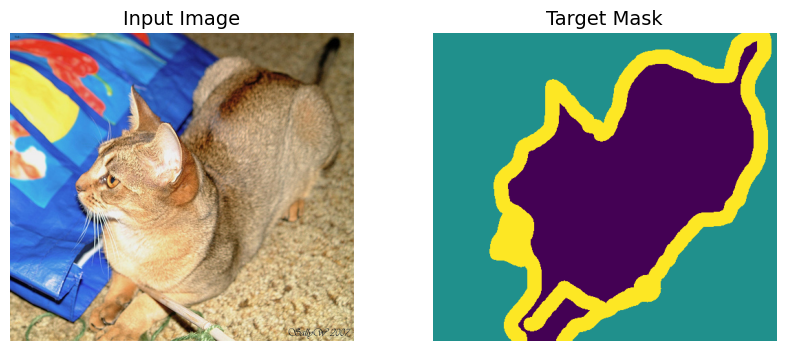

In [4]:
from keras.utils import load_img, img_to_array, array_to_img

# The original labels are 1 (foreground), 2 (background), 3 (contour)
# Here they are converted to 0, 127, 254 to enhance the visualization of the mask

def display_target(target_array):
    normalized_array = (target_array.astype("uint8") - 1) * 127
    plt.axis("off")
    plt.imshow(normalized_array[:, :, 0])

# Select one image from dataset. Change the index to check other examples
index = 9

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Input Image")
plt.axis("off")
plt.imshow(load_img(input_img_paths[index]))

plt.subplot(1,2,2)
plt.title("Target Mask")
plt.axis("off")
mask = img_to_array(load_img(target_paths[index], color_mode="grayscale"))
plt.imshow(mask[:,:,0])

plt.show()

**2. Create Datasets**

In [5]:
# Datasets are stored in numpy arrays

import random

img_size = (200, 200)
num_imgs = len(input_img_paths)

random.Random(1337).shuffle(input_img_paths)
random.Random(1337).shuffle(target_paths)

def path_to_input_image(path):
    return img_to_array(load_img(path, target_size=img_size))

def path_to_target(path):
    img = img_to_array(
        load_img(path, target_size=img_size, color_mode="grayscale")
    )
    img = img.astype("uint8") - 1
    return img

input_imgs = np.zeros((num_imgs,) + img_size + (3,), dtype="float32")
targets = np.zeros((num_imgs,) + img_size + (1,), dtype="uint8")
for i in range(num_imgs):
    input_imgs[i] = path_to_input_image(input_img_paths[i])
    targets[i] = path_to_target(target_paths[i])

In [6]:
num_val_samples = 1000
train_input_imgs = input_imgs[:-num_val_samples]
train_targets = targets[:-num_val_samples]
val_input_imgs = input_imgs[-num_val_samples:]
val_targets = targets[-num_val_samples:]

In [7]:
# Size of datasets

print('Training dataset: ', train_input_imgs.shape , train_targets.shape)
print('Validation dataset: ', val_input_imgs.shape , val_targets.shape)


Training dataset:  (6390, 200, 200, 3) (6390, 200, 200, 1)
Validation dataset:  (1000, 200, 200, 3) (1000, 200, 200, 1)


**3. Create a Neural Network for Image Segmentation**

In [8]:

inputs = keras.Input(shape=(200,200,3))

x = layers.Rescaling(1.0 / 255)(inputs)

x = layers.Conv2D(64, 3, strides=2, activation="relu", padding="same")(x)
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = layers.Conv2D(128, 3, strides=2, activation="relu", padding="same")(x)
x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
x = layers.Conv2D(256, 3, strides=2, padding="same", activation="relu")(x)
x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)

x = layers.Conv2DTranspose(256, 3, activation="relu", padding="same")(x)
x = layers.Conv2DTranspose(256, 3, strides=2, activation="relu", padding="same")(x)
x = layers.Conv2DTranspose(128, 3, activation="relu", padding="same")(x)
x = layers.Conv2DTranspose(128, 3, strides=2, activation="relu", padding="same")(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", padding="same")(x)
x = layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(x)

outputs = layers.Conv2D(3, 1, activation="softmax", padding="same")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 100, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 50, 50, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 25, 25, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 50, 50, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 50, 50, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 100, 100, 128)  │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 100, 100, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 200, 200, 64)   │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 200, 200, 3)    │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,879,107 (10.98 MB)

 Trainable params: 2,879,107 (10.98 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Define the loss function

foreground_iou = keras.metrics.IoU(
    num_classes=3,
    target_class_ids=(0,),
    name="foreground_iou",
    sparse_y_true=True,
    sparse_y_pred=False,
)

**4. Model Training**

In [10]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=[foreground_iou],
)

history = model.fit(
    train_input_imgs,
    train_targets,
    epochs=20,
    batch_size=32,
    validation_data=(val_input_imgs, val_targets),
)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 99s 360ms/step - foreground_iou: 0.1559 - loss: 0.8991 - val_foreground_iou: 0.4321 - val_loss: 0.8159
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 48s 238ms/step - foreground_iou: 0.4665 - loss: 0.7233 - val_foreground_iou: 0.5404 - val_loss: 0.6427
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 49s 243ms/step - foreground_iou: 0.5543 - loss: 0.5934 - val_foreground_iou: 0.6128 - val_loss: 0.5156
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 49s 246ms/step - foreground_iou: 0.6183 - loss: 0.5064 - val_foreground_iou: 0.6418 - val_loss: 0.4690
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 50s 248ms/step - foreground_iou: 0.6499 - loss: 0.4658 - val_foreground_iou: 0.6575 - val_loss: 0.4508
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 50s 249ms/step - foreground_iou: 0.6685 - loss: 0.4410 - val_foreground_iou: 0.6858 - val_loss: 0.4191
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 50s 251ms/step - foreground_iou: 0.6758 - loss: 0.4286 - val_foreground_iou: 0.6812 - val_loss: 0.4253

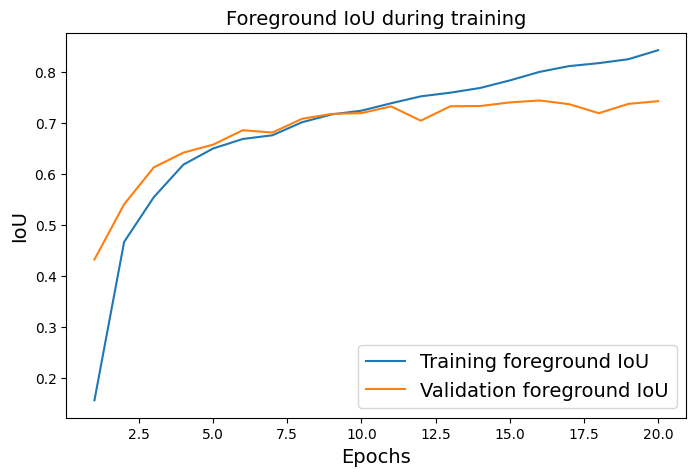

In [11]:
epochs = range(1, len(history.history["foreground_iou"]) + 1)

train_iou = history.history["foreground_iou"]
val_iou = history.history["val_foreground_iou"]

plt.figure(figsize=(8,5))
plt.plot(epochs, train_iou, label="Training foreground IoU")
plt.plot(epochs, val_iou, label="Validation foreground IoU")
plt.title("Foreground IoU during training")
plt.xlabel("Epochs")
plt.ylabel("IoU")
plt.legend()
plt.show()

**5. Model Testing**

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


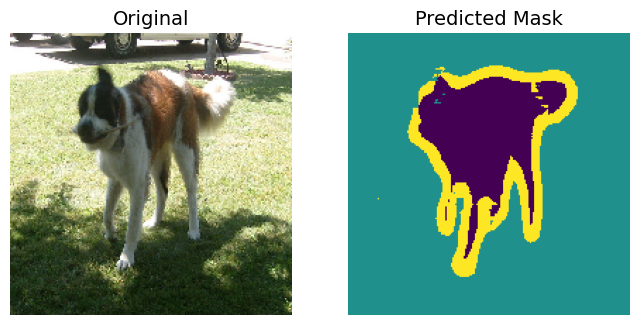

In [12]:
# Test the effectiveness of the model on several validation images

i = 12
test_image = val_input_imgs[i]

mask = model.predict(np.expand_dims(test_image, 0))[0]

mask = np.argmax(mask, axis=-1)
mask = mask * 127

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.axis("off")
plt.imshow(array_to_img(test_image))

plt.subplot(1,2,2)
plt.title("Predicted Mask")
plt.axis("off")
plt.imshow(mask)

plt.imshow(mask, cmap="viridis")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


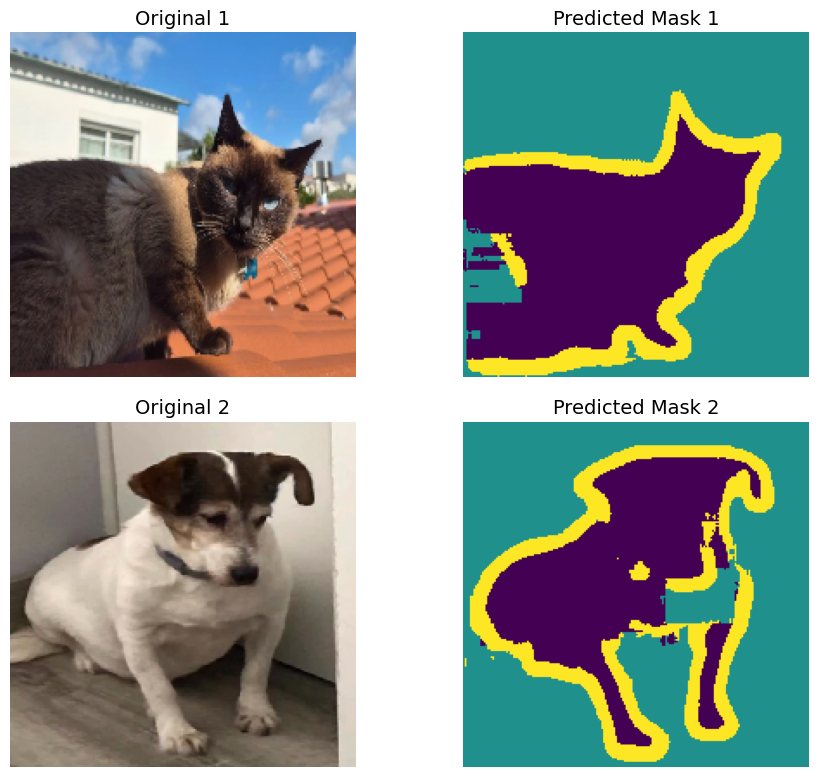

In [16]:
# Upload a new image to the working directory
# Check how the model behaves

image_names = ['AA.jpg', 'AAA.jpg']  # mete aqui os nomes das 2 fotos

plt.figure(figsize=(10, 8))

for i, Image_Name in enumerate(image_names):

    img = keras.utils.load_img(Image_Name, target_size=img_size)
    test_image = keras.utils.img_to_array(img)

    pred = model.predict(np.expand_dims(test_image, 0))[0]

    mask = np.argmax(pred, axis=-1)
    mask = mask * 127

    # Original
    plt.subplot(len(image_names), 2, 2*i + 1)
    plt.title(f"Original {i+1}")
    plt.axis("off")
    plt.imshow(array_to_img(test_image))

    # Predição
    plt.subplot(len(image_names), 2, 2*i + 2)
    plt.title(f"Predicted Mask {i+1}")
    plt.axis("off")
    plt.imshow(mask, cmap="viridis")

plt.tight_layout()
plt.show()